# Titanic Dataset - PyTorch Neural Network Classification

This notebook implements a deep learning approach using PyTorch for Titanic survival classification.

## Objectives:
1. Load preprocessed data
2. Create PyTorch datasets and dataloaders
3. Build neural network architectures
4. Train models with different configurations
5. Implement training loop with validation
6. Evaluate model performance
7. Visualize training progress
8. Compare with traditional ML models
9. Save trained models

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Load and Prepare Data

In [2]:
# Load preprocessed data
data_path = Path('../data/processed/titanic_processed.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (891, 29)

Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'HasCabin', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teenager', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']

First few rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,...,AgeGroup_Adult,AgeGroup_Senior,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,22.0,1,0,7.2500,2,0,3.62500,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,0,35.64165,...,1,0,0,1,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,1,1,7.92500,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,2,0,26.55000,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,1,1,8.05000,...,0,0,0,0,0,0,0,0,0,1


In [3]:
# Separate features and target
X = df.drop('Survived', axis=1).values
y = df['Survived'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Class {label}: {count} ({count/len(y)*100:.2f}%)")

Features shape: (891, 28)
Target shape: (891,)
Number of features: 28

Class distribution:
Class 0: 549 (61.62%)
Class 1: 342 (38.38%)


In [4]:
# Split data into train, validation, and test sets
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Second split: 75% train, 25% validation (of the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set size: 534 (59.9%)
Validation set size: 178 (20.0%)
Test set size: 179 (20.1%)


In [5]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print(f"\nScaled features statistics (training set):")
print(f"Mean: {X_train_scaled.mean(axis=0)[:5]}...")  # Show first 5
print(f"Std: {X_train_scaled.std(axis=0)[:5]}...")  # Show first 5

Feature scaling completed.

Scaled features statistics (training set):
Mean: [ 1.62375315e-16  7.11041712e-17  7.59639958e-17  1.14348813e-17
 -2.61962736e-17]...
Std: [1. 1. 1. 1. 1.]...


In [6]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test)

print("Data converted to PyTorch tensors.")
print(f"Training tensor shape: {X_train_tensor.shape}")
print(f"Validation tensor shape: {X_val_tensor.shape}")
print(f"Test tensor shape: {X_test_tensor.shape}")

Data converted to PyTorch tensors.
Training tensor shape: torch.Size([534, 28])
Validation tensor shape: torch.Size([178, 28])
Test tensor shape: torch.Size([179, 28])


In [7]:
# Create datasets and dataloaders
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Batch size: 32
Number of training batches: 17
Number of validation batches: 6
Number of test batches: 6


## 2. Define Neural Network Architectures

In [8]:
class SimpleNN(nn.Module):
    """Simple feedforward neural network with 2 hidden layers."""
    
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32, dropout_rate=0.3):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc3 = nn.Linear(hidden_size2, 1)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        x = torch.sigmoid(x)
        return x


class DeepNN(nn.Module):
    """Deeper neural network with 4 hidden layers."""
    
    def __init__(self, input_size, hidden_sizes=[128, 64, 32, 16], dropout_rate=0.3):
        super(DeepNN, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0])
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1])
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2])
        self.dropout3 = nn.Dropout(dropout_rate)
        
        self.fc4 = nn.Linear(hidden_sizes[2], hidden_sizes[3])
        self.bn4 = nn.BatchNorm1d(hidden_sizes[3])
        self.dropout4 = nn.Dropout(dropout_rate)
        
        self.fc5 = nn.Linear(hidden_sizes[3], 1)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        
        x = F.relu(self.bn4(self.fc4(x)))
        x = self.dropout4(x)
        
        x = torch.sigmoid(self.fc5(x))
        return x


class ResidualBlock(nn.Module):
    """Residual block with skip connection."""
    
    def __init__(self, hidden_size, dropout_rate=0.3):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        
    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.bn2(self.fc2(x))
        x += residual  # Skip connection
        x = F.relu(x)
        return x


class ResNet(nn.Module):
    """Neural network with residual connections."""
    
    def __init__(self, input_size, hidden_size=64, num_blocks=2, dropout_rate=0.3):
        super(ResNet, self).__init__()
        
        self.fc_in = nn.Linear(input_size, hidden_size)
        self.bn_in = nn.BatchNorm1d(hidden_size)
        
        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_size, dropout_rate) for _ in range(num_blocks)
        ])
        
        self.fc_out = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        x = F.relu(self.bn_in(self.fc_in(x)))
        
        for block in self.blocks:
            x = block(x)
        
        x = torch.sigmoid(self.fc_out(x))
        return x

print("Neural network architectures defined:")
print("1. SimpleNN - 2 hidden layers")
print("2. DeepNN - 4 hidden layers")
print("3. ResNet - Residual connections")

Neural network architectures defined:
1. SimpleNN - 2 hidden layers
2. DeepNN - 4 hidden layers
3. ResNet - Residual connections


## 3. Training Functions

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.unsqueeze(1)  # Add dimension for BCE loss
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.unsqueeze(1)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(outputs.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_predictions, all_labels, all_probabilities


def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs, device, scheduler=None, early_stopping_patience=15):
    """Complete training loop with early stopping."""
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
        
        # Update learning rate if scheduler is provided
        if scheduler is not None:
            scheduler.step(val_loss)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= early_stopping_patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    print(f"\nBest validation loss: {best_val_loss:.4f}")
    
    return model, history

print("Training functions defined.")

Training functions defined.


## 4. Evaluation Functions

In [10]:
def evaluate_model(model, test_loader, device):
    """Evaluate model on test set."""
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            predicted = (outputs > 0.5).float()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probabilities.extend(outputs.cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions).flatten()
    all_labels = np.array(all_labels).flatten()
    all_probabilities = np.array(all_probabilities).flatten()
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions)
    recall = recall_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions)
    roc_auc = roc_auc_score(all_labels, all_probabilities)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probabilities
    }


def plot_training_history(history, model_name):
    """Plot training and validation metrics."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Training History - Loss ({model_name})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Accuracy')
    axes[1].plot(history['val_acc'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Training History - Accuracy ({model_name})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(labels, predictions, model_name):
    """Plot confusion matrix."""
    cm = confusion_matrix(labels, predictions)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Did not survive', 'Survived'],
                yticklabels=['Did not survive', 'Survived'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


def plot_roc_curve(labels, probabilities, model_name):
    """Plot ROC curve."""
    fpr, tpr, _ = roc_curve(labels, probabilities)
    roc_auc = roc_auc_score(labels, probabilities)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Evaluation functions defined.")

Evaluation functions defined.


## 5. Train Models

### 5.1 Simple Neural Network

In [11]:
print("="*80)
print("TRAINING SIMPLE NEURAL NETWORK")
print("="*80)

# Initialize model
input_size = X_train.shape[1]
simple_model = SimpleNN(input_size, hidden_size1=64, hidden_size2=32, dropout_rate=0.3).to(device)

# Print model architecture
print(f"\nModel Architecture:")
print(simple_model)
print(f"\nTotal parameters: {sum(p.numel() for p in simple_model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in simple_model.parameters() if p.requires_grad)}")

# Define loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(simple_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# Train
print("\nTraining...")
simple_model, simple_history = train_model(
    simple_model, train_loader, val_loader, criterion, optimizer,
    num_epochs=100, device=device, scheduler=scheduler, early_stopping_patience=15
)

TRAINING SIMPLE NEURAL NETWORK

Model Architecture:
SimpleNN(
  (fc1): Linear(in_features=28, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 4161
Trainable parameters: 4161

Training...
Epoch [1/100] - Train Loss: 0.6785, Train Acc: 0.6011 - Val Loss: 0.6315, Val Acc: 0.7022
Epoch [10/100] - Train Loss: 0.4238, Train Acc: 0.8090 - Val Loss: 0.4387, Val Acc: 0.8258
Epoch [20/100] - Train Loss: 0.3805, Train Acc: 0.8577 - Val Loss: 0.4377, Val Acc: 0.8258
Epoch [30/100] - Train Loss: 0.3682, Train Acc: 0.8521 - Val Loss: 0.4481, Val Acc: 0.8258

Early stopping triggered at epoch 35

Best validation loss: 0.4

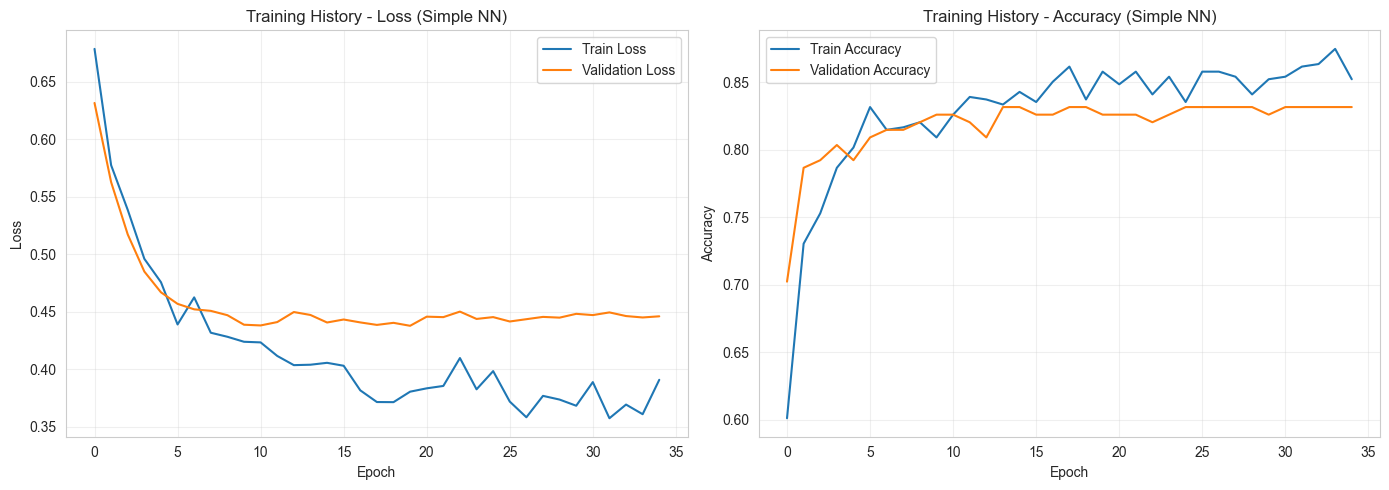

In [12]:
# Plot training history
plot_training_history(simple_history, 'Simple NN')

In [13]:
# Evaluate on test set
simple_results = evaluate_model(simple_model, test_loader, device)

print("\nTest Set Results:")
print(f"Accuracy: {simple_results['accuracy']:.4f}")
print(f"Precision: {simple_results['precision']:.4f}")
print(f"Recall: {simple_results['recall']:.4f}")
print(f"F1 Score: {simple_results['f1']:.4f}")
print(f"ROC AUC: {simple_results['roc_auc']:.4f}")

print("\nClassification Report:")
print(classification_report(simple_results['labels'], simple_results['predictions'],
                          target_names=['Did not survive', 'Survived']))


Test Set Results:
Accuracy: 0.7989
Precision: 0.7619
Recall: 0.6957
F1 Score: 0.7273
ROC AUC: 0.8142

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.82      0.86      0.84       110
       Survived       0.76      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.79      0.78      0.78       179
   weighted avg       0.80      0.80      0.80       179



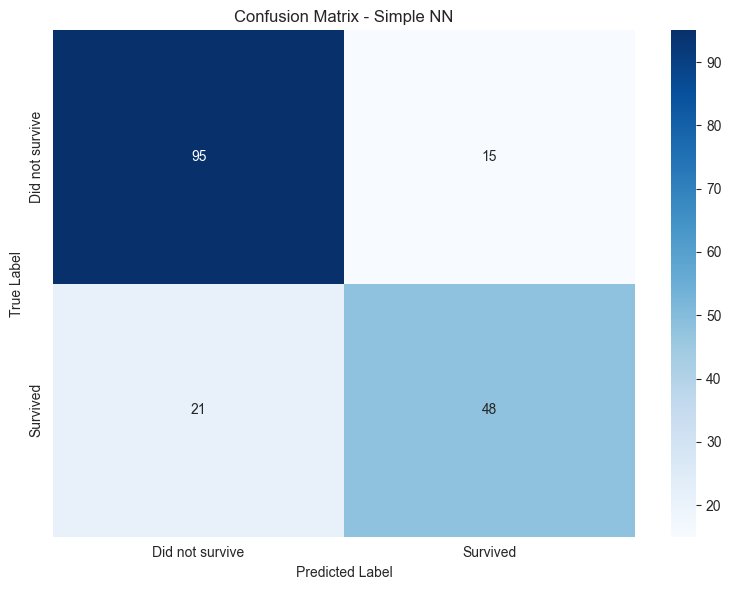

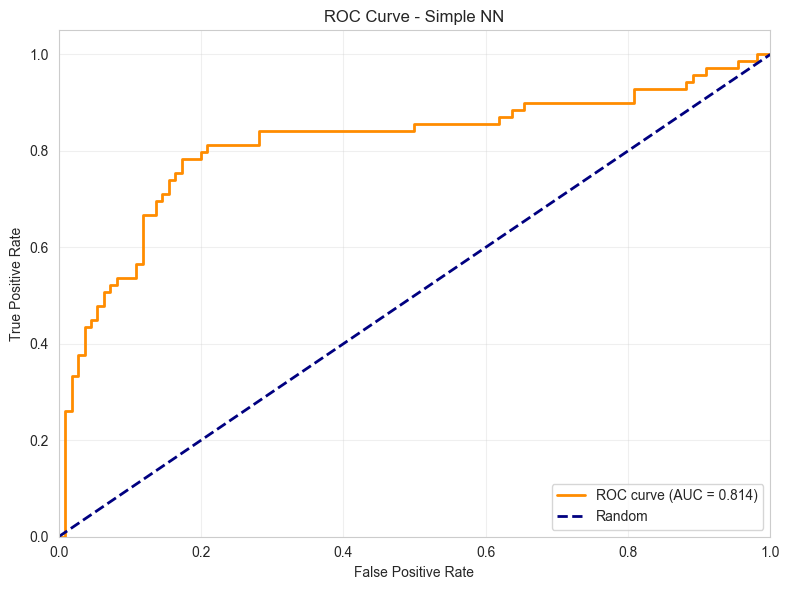

In [14]:
# Visualizations
plot_confusion_matrix(simple_results['labels'], simple_results['predictions'], 'Simple NN')
plot_roc_curve(simple_results['labels'], simple_results['probabilities'], 'Simple NN')

### 5.2 Deep Neural Network

In [15]:
print("="*80)
print("TRAINING DEEP NEURAL NETWORK")
print("="*80)

# Initialize model
deep_model = DeepNN(input_size, hidden_sizes=[128, 64, 32, 16], dropout_rate=0.4).to(device)

print(f"\nModel Architecture:")
print(deep_model)
print(f"\nTotal parameters: {sum(p.numel() for p in deep_model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in deep_model.parameters() if p.requires_grad)}")

# Define loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(deep_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# Train
print("\nTraining...")
deep_model, deep_history = train_model(
    deep_model, train_loader, val_loader, criterion, optimizer,
    num_epochs=100, device=device, scheduler=scheduler, early_stopping_patience=15
)

TRAINING DEEP NEURAL NETWORK

Model Architecture:
DeepNN(
  (fc1): Linear(in_features=28, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.4, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.4, inplace=False)
  (fc4): Linear(in_features=32, out_features=16, bias=True)
  (bn4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout4): Dropout(p=0.4, inplace=False)
  (fc5): Linear(in_features=16, out_features=1, bias=True)
)

Total parameters: 15073
Trainable parameters: 15073

Training...
Epoch [1/100] - Train Loss: 0.6596, Trai

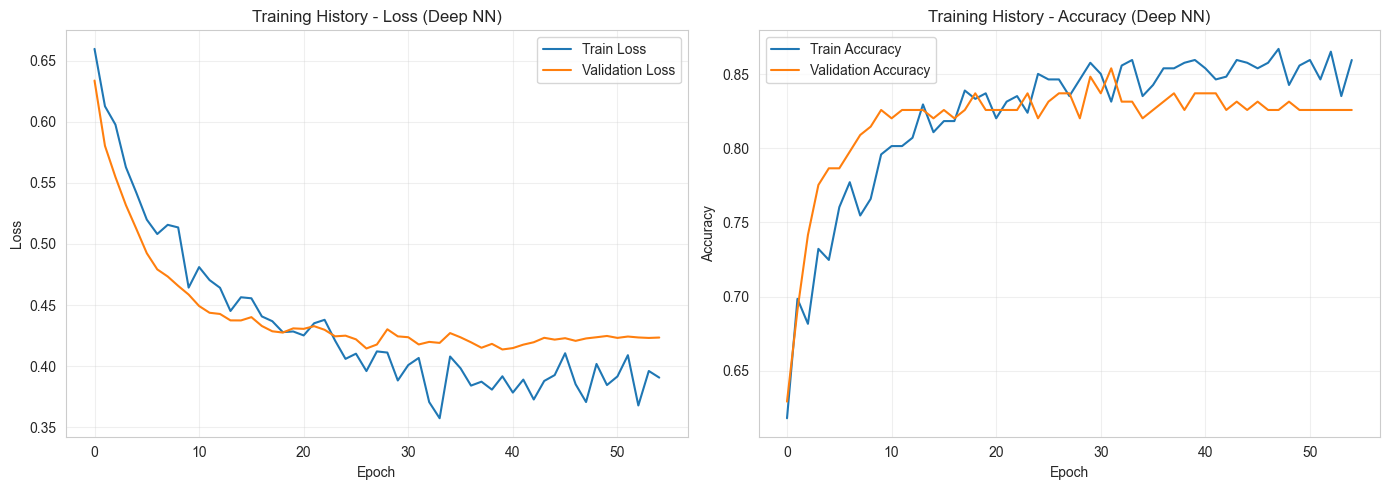

In [16]:
# Plot training history
plot_training_history(deep_history, 'Deep NN')

In [17]:
# Evaluate on test set
deep_results = evaluate_model(deep_model, test_loader, device)

print("\nTest Set Results:")
print(f"Accuracy: {deep_results['accuracy']:.4f}")
print(f"Precision: {deep_results['precision']:.4f}")
print(f"Recall: {deep_results['recall']:.4f}")
print(f"F1 Score: {deep_results['f1']:.4f}")
print(f"ROC AUC: {deep_results['roc_auc']:.4f}")

print("\nClassification Report:")
print(classification_report(deep_results['labels'], deep_results['predictions'],
                          target_names=['Did not survive', 'Survived']))


Test Set Results:
Accuracy: 0.7933
Precision: 0.7667
Recall: 0.6667
F1 Score: 0.7132
ROC AUC: 0.8206

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.81      0.87      0.84       110
       Survived       0.77      0.67      0.71        69

       accuracy                           0.79       179
      macro avg       0.79      0.77      0.78       179
   weighted avg       0.79      0.79      0.79       179



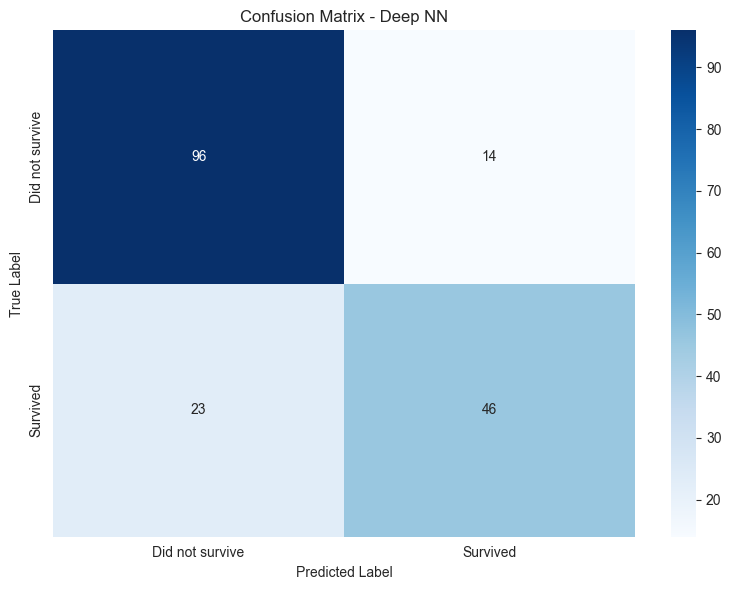

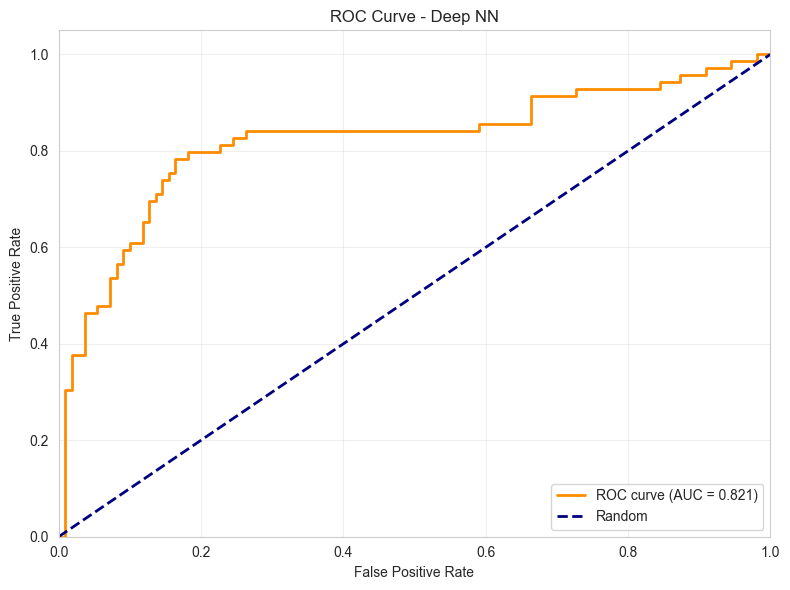

In [18]:
# Visualizations
plot_confusion_matrix(deep_results['labels'], deep_results['predictions'], 'Deep NN')
plot_roc_curve(deep_results['labels'], deep_results['probabilities'], 'Deep NN')

## 6. Compare All PyTorch Models

In [20]:
# Compile results
pytorch_comparison = pd.DataFrame([
    {
        'Model': 'Simple NN',
        'Accuracy': simple_results['accuracy'],
        'Precision': simple_results['precision'],
        'Recall': simple_results['recall'],
        'F1 Score': simple_results['f1'],
        'ROC AUC': simple_results['roc_auc']
    },
    {
        'Model': 'Deep NN',
        'Accuracy': deep_results['accuracy'],
        'Precision': deep_results['precision'],
        'Recall': deep_results['recall'],
        'F1 Score': deep_results['f1'],
        'ROC AUC': deep_results['roc_auc']
    },
]).set_index('Model')

print("="*80)
print("PYTORCH MODELS COMPARISON")
print("="*80)
print(pytorch_comparison.round(4))

PYTORCH MODELS COMPARISON
           Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                    
Simple NN    0.7989     0.7619  0.6957    0.7273   0.8142
Deep NN      0.7933     0.7667  0.6667    0.7132   0.8206


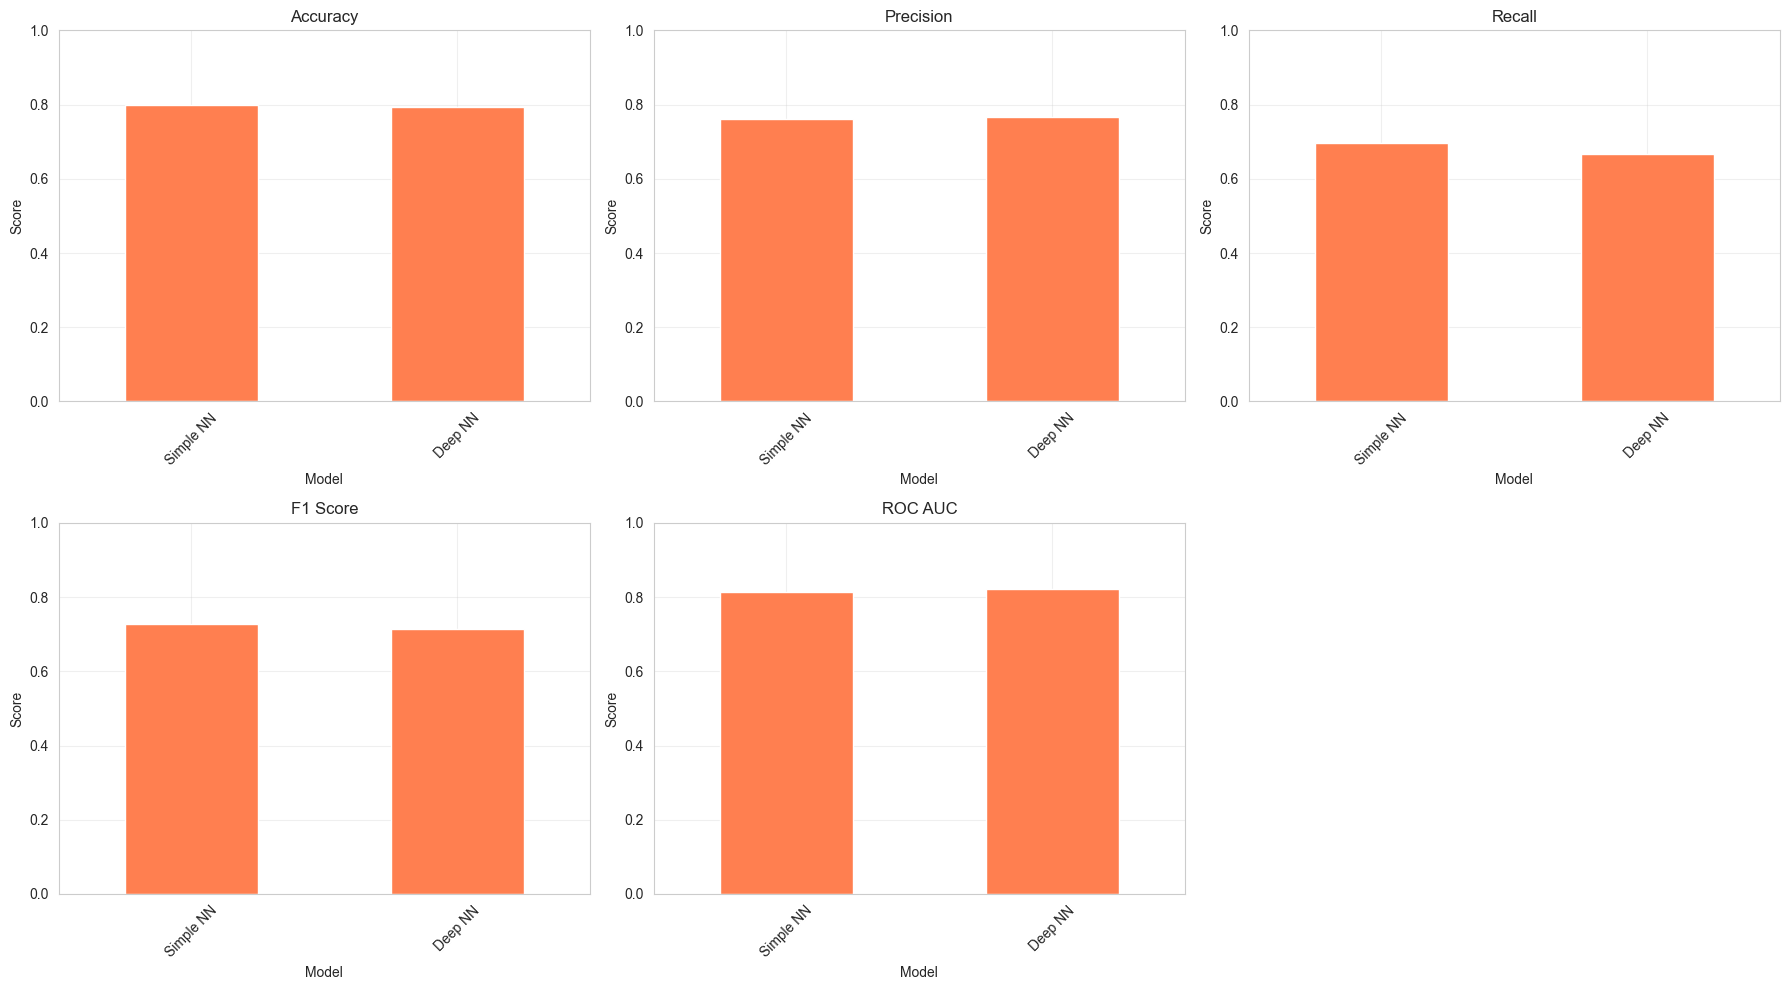

In [21]:
# Visualize comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    pytorch_comparison[metric].plot(kind='bar', ax=ax, color='coral')
    ax.set_title(metric)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

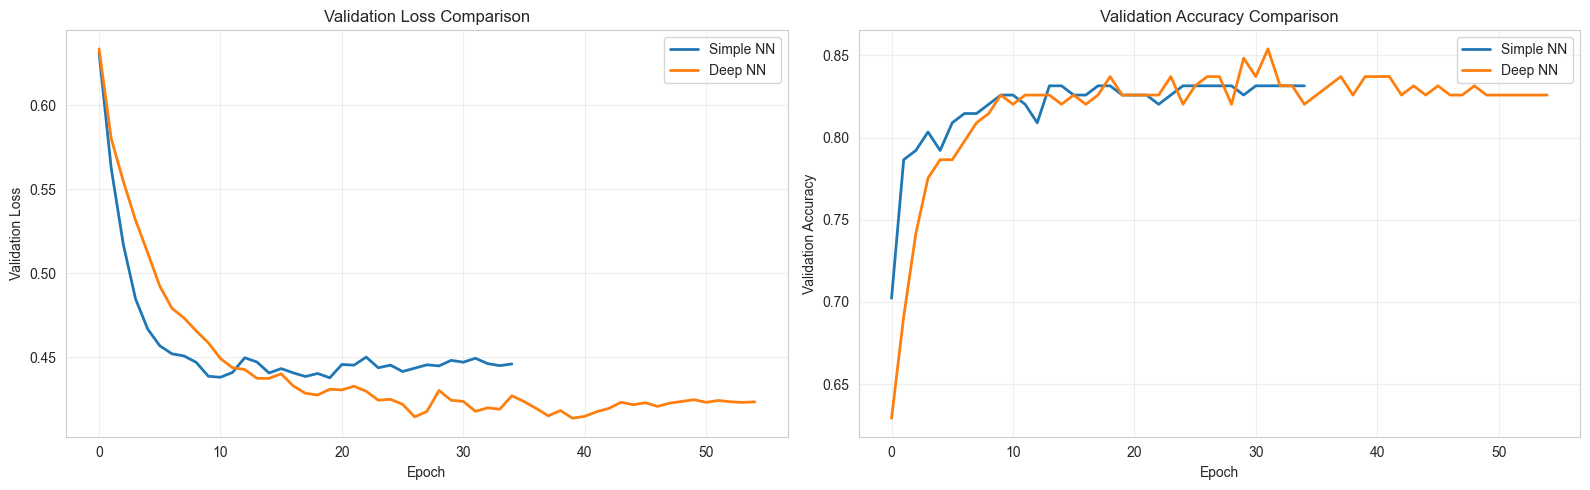

In [22]:
# Compare training histories
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss comparison
axes[0].plot(simple_history['val_loss'], label='Simple NN', linewidth=2)
axes[0].plot(deep_history['val_loss'], label='Deep NN', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(simple_history['val_acc'], label='Simple NN', linewidth=2)
axes[1].plot(deep_history['val_acc'], label='Deep NN', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save PyTorch Models

In [23]:
# Create models directory
models_dir = Path('../models/pytorch')
models_dir.mkdir(parents=True, exist_ok=True)

# Save models
torch.save({
    'model_state_dict': simple_model.state_dict(),
    'model_architecture': 'SimpleNN',
    'input_size': input_size,
    'hidden_size1': 64,
    'hidden_size2': 32,
    'dropout_rate': 0.3,
    'history': simple_history,
    'test_results': simple_results
}, models_dir / 'simple_nn.pth')

torch.save({
    'model_state_dict': deep_model.state_dict(),
    'model_architecture': 'DeepNN',
    'input_size': input_size,
    'hidden_sizes': [128, 64, 32, 16],
    'dropout_rate': 0.4,
    'history': deep_history,
    'test_results': deep_results
}, models_dir / 'deep_nn.pth')
# Save scaler
with open(models_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("PyTorch models saved:")
print(f"  - {models_dir / 'simple_nn.pth'}")
print(f"  - {models_dir / 'deep_nn.pth'}")
print(f"  - {models_dir / 'scaler.pkl'}")

PyTorch models saved:
  - ..\models\pytorch\simple_nn.pth
  - ..\models\pytorch\deep_nn.pth
  - ..\models\pytorch\scaler.pkl
